# Inference and Evaluation of Saccharomyces Cerevisiae FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on Saccharomyces Cerevisiae - yeast9 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [1]:
import os
import random
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from cobra.io import read_sbml_model

from yeast9_data import load_data, prepare_tensors, set_seed
# Uses the older non-injected FluxTransformer definition below.

%matplotlib inline
pd.set_option('display.max_rows', None)


In [2]:
# Older Yeast9 FluxTransformer used by the saved checkpoint.
# This version evaluates all tokens directly and does not use injected input tokens.
class AttentionBlock(nn.Module):
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)
        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        x_norm = self.layer_norm(x)
        attn_out, attn_weights = self.mha(
            x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False
        )
        x_out = attn_out + x
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)
        c_att = (c_heads * alpha).sum(dim=1)
        c_out = c_att + c
        return x_out, c_out


class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()
        self.layer_norm = nn.LayerNorm(d_model + 1)
        self.linear1 = nn.Linear(d_model + 1, d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(d_ff, d_model + 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)
        return output + y


class FluxTransformerLayer(nn.Module):
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)

    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        return updated_x, updated_c


class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=4195,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
        input_length=64,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        batch_size = c.size(0)
        input_indices = torch.arange(self.input_length, device=c.device)
        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)
        x = self.input_embedding(y)
        c_subset = c[:, selected_indices, :]

        for layer in self.layers:
            x, c_subset = layer(x, c_subset)

        if return_embedding:
            return x, selected_indices
        return c_subset


In [3]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout'],
        input_length=config.get('n_inputs', 64)
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']


### Plotting Functions

In [4]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    if log_scale:
        plt.yscale('log')
        
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [5]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    label_map = {
        'r_2111': 'Biomass Yeast9',
        'r_0438': 'Cytochrome-c oxidase',
        'r_1110': 'ADP/ATP transporter',
        'r_0226': 'ATP synthase',
        'r_1245': 'Phosphate transport',
        'r_1021': 'Succinate dehydrogenase',
        'r_2100': 'water exchange',
        'r_1672': 'carbon dioxide exchange',
    }
    display_label = label_map.get(display_label, display_label)

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot (top-right): center around y=0
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
    if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
        res_abs_max = 1.0
    axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    axs[0, 1].grid(True)

    # Error distribution (bottom-left): center around x=0
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].axvline(x=0, color='r', linestyle='-')
    err_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
    if (not np.isfinite(err_abs_max)) or (err_abs_max == 0.0):
        err_abs_max = 1.0
    axs[1, 0].set_xlim(-err_abs_max, err_abs_max)
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()

In [6]:
def plot_flux(
    model,
    X_test,
    y_test, 
    input_cols,
    output_cols,
    flux_name: str,
    save_path=None,
    batch_size=16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Plotting for a single flux column.
    """

    # find target column index
    try:
        target_idx = output_cols.index(flux_name) + len(input_cols)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    print(f"Plotting flux '{flux_name}' (column index {target_idx})")

    model = model.to(device)
    model.eval()

    pred_vals = []
    true_vals = []

    with torch.no_grad():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i+batch_size].to(device)
            yb_true = y_test[i:i+batch_size]

            c = xb.unsqueeze(-1)

            yb_pred = model(c)

            # Slice only the flux we care
            yb_pred_flux = yb_pred.squeeze(-1)[:, target_idx].detach().cpu().numpy()
            yb_true_flux = yb_true[:, target_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.startswith('cuda'):
                torch.cuda.empty_cache()

    # concatenate all batches
    y_pred_flux = np.concatenate(pred_vals, axis=0)
    y_true_flux = np.concatenate(true_vals, axis=0)

    print(f"{flux_name} y_true range: {y_true_flux.min()} .. {y_true_flux.max()}")
    print(f"{flux_name} y_pred range: {y_pred_flux.min()} .. {y_pred_flux.max()}")

    # Per-flux metrics for the currently plotted target
    try:
        r2_flux = r2_score(y_true_flux, y_pred_flux)
    except Exception:
        r2_flux = float('nan')
    mae_flux = mean_absolute_error(y_true_flux, y_pred_flux)
    rmse_flux = np.sqrt(np.mean((y_true_flux - y_pred_flux) ** 2))
    print(f"R2: {r2_flux:.4f}")
    print(f"MAE: {mae_flux:.6f}")
    print(f"RMSE: {rmse_flux:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true_flux,
        y_pred=y_pred_flux,
        label=flux_name,
        save_path=save_path
    )


### Load model

In [7]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
model_name = "yeast9_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/yeast9_d256_h8_l3_ff1024/yeast9_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,449,377

Data information:
Dataset: ./data/2025-11-07_yeast9_data_246923_samples.csv
Training samples: 197538
Test samples: 49385


### Load data

In [9]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/yeast9_test_data.csv"

#X, y, input_cols, output_cols = load_data(data_info['dataset'])
X, y, input_cols, output_cols = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

# Map Yeast9 reaction IDs to reader-facing names for diagnostic tables.
yeast9_gem = read_sbml_model('./models/yeast-GEM.xml')
reaction_name_map = {rxn.id: rxn.name for rxn in yeast9_gem.reactions}
missing_annotations = sorted(set(output_cols) - set(reaction_name_map))
assert not missing_annotations, f'Missing Yeast9 annotations: {missing_annotations[:10]}'


Loaded data with 49393 samples from ./data/yeast9_test_data.csv
Number of input features: 64
Number of output targets: 4131
Training samples: 39514
Test samples: 9879


In [10]:
model.eval()

FluxTransformer(
  (input_embedding): Embedding(4195, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

### Plot Results

In [11]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

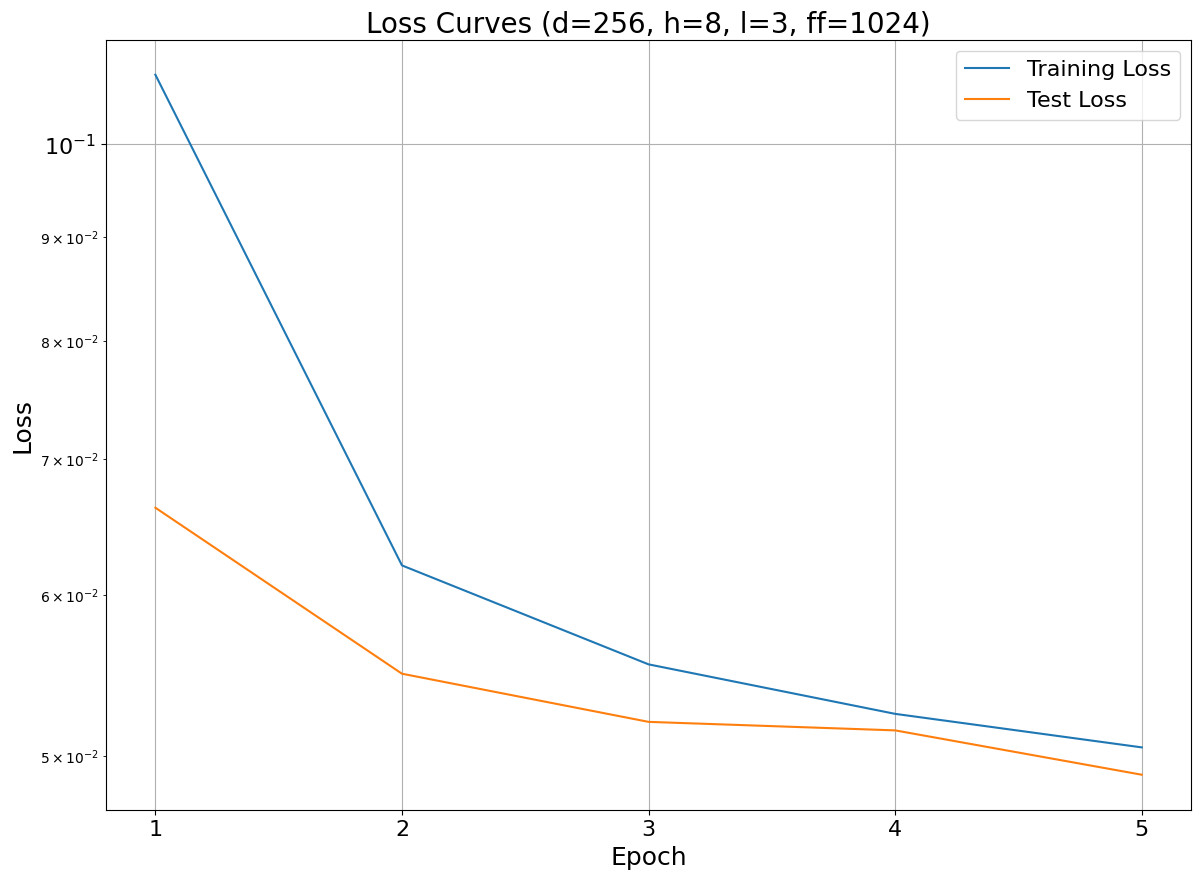

In [12]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
    )

r_2111:
------------------------------------------------------------
Plotting flux 'r_2111' (column index 1563)
r_2111 y_true range: -5.2059657989654215e-14 .. 2.89458966255188
r_2111 y_pred range: 0.031713396310806274 .. 2.8635923862457275
R2: 0.9858
MAE: 0.052342
RMSE: 0.066970


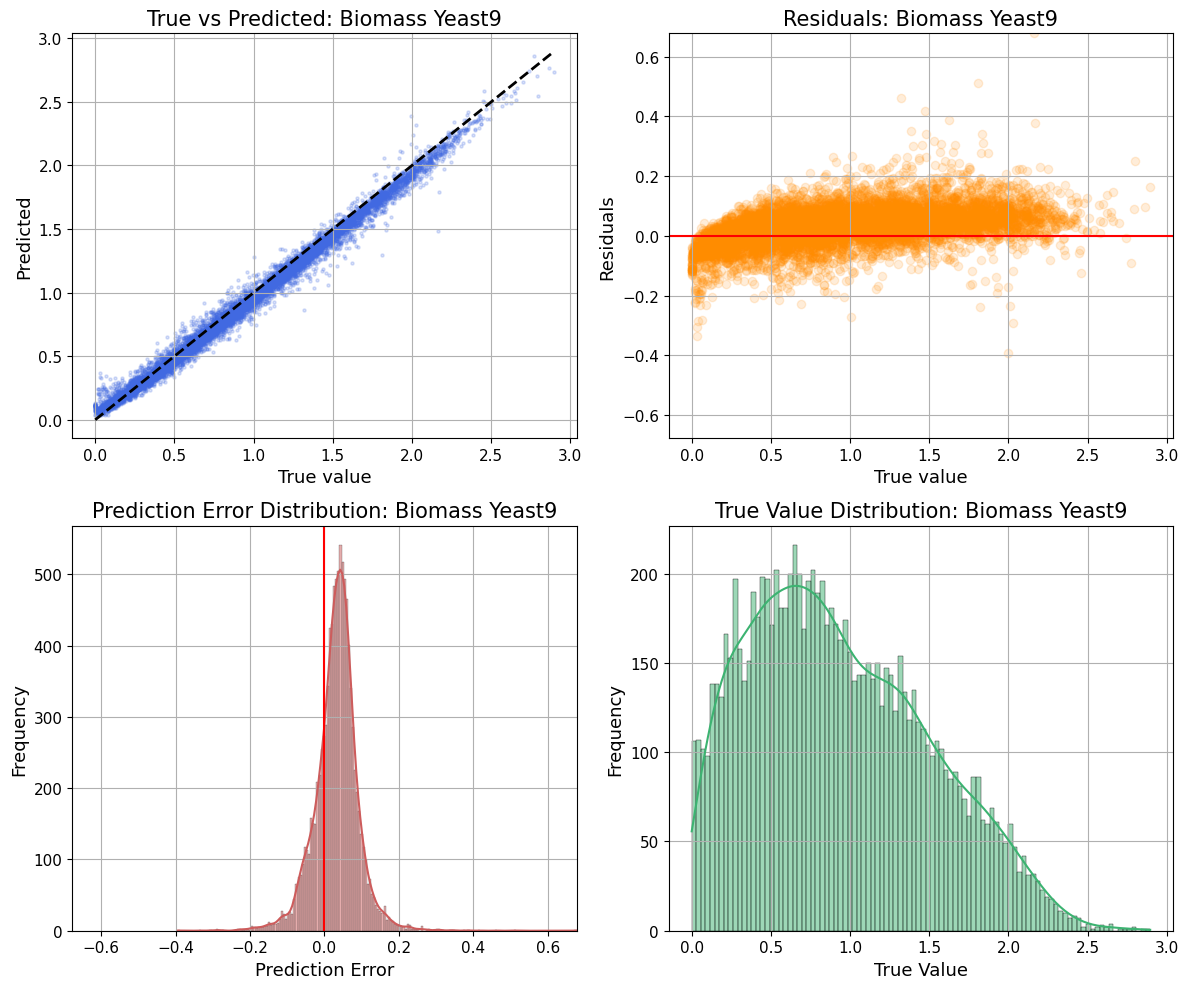

r_1110:
------------------------------------------------------------
Plotting flux 'r_1110' (column index 923)
r_1110 y_true range: 0.0 .. 150.24110412597656
r_1110 y_pred range: 0.4117259979248047 .. 147.9962158203125
R2: 0.9923
MAE: 1.534296
RMSE: 3.083488


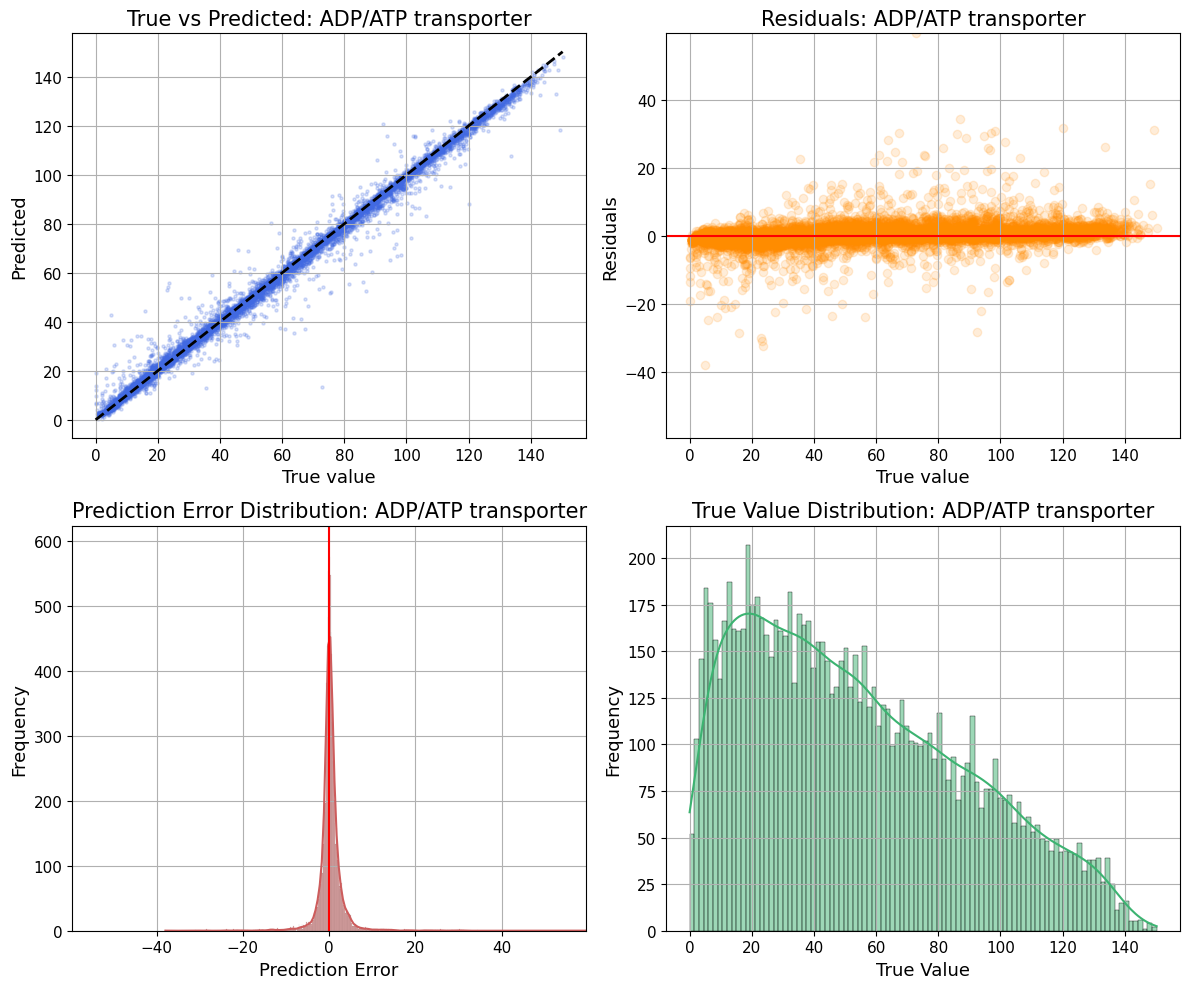

r_0438:
------------------------------------------------------------
Plotting flux 'r_0438' (column index 398)
r_0438 y_true range: 0.0 .. 195.50930786132812
r_0438 y_pred range: 1.0642890930175781 .. 192.00091552734375
R2: 0.9928
MAE: 1.990709
RMSE: 4.183064


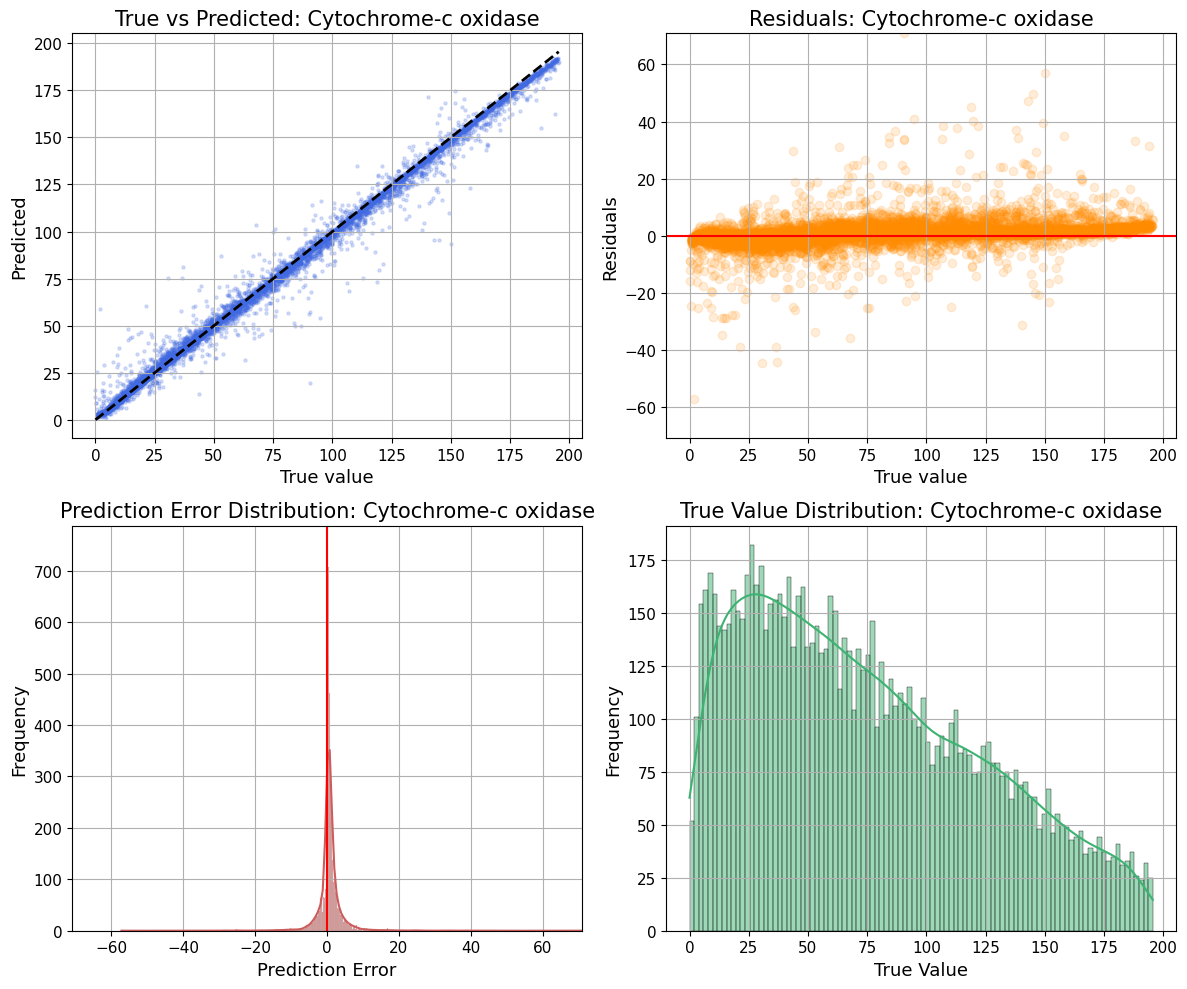

r_0226:
------------------------------------------------------------
Plotting flux 'r_0226' (column index 266)
r_0226 y_true range: 0.04625378176569939 .. 146.4228057861328
r_0226 y_pred range: 0.8086576461791992 .. 131.109619140625
R2: 0.9916
MAE: 1.566906
RMSE: 2.949417


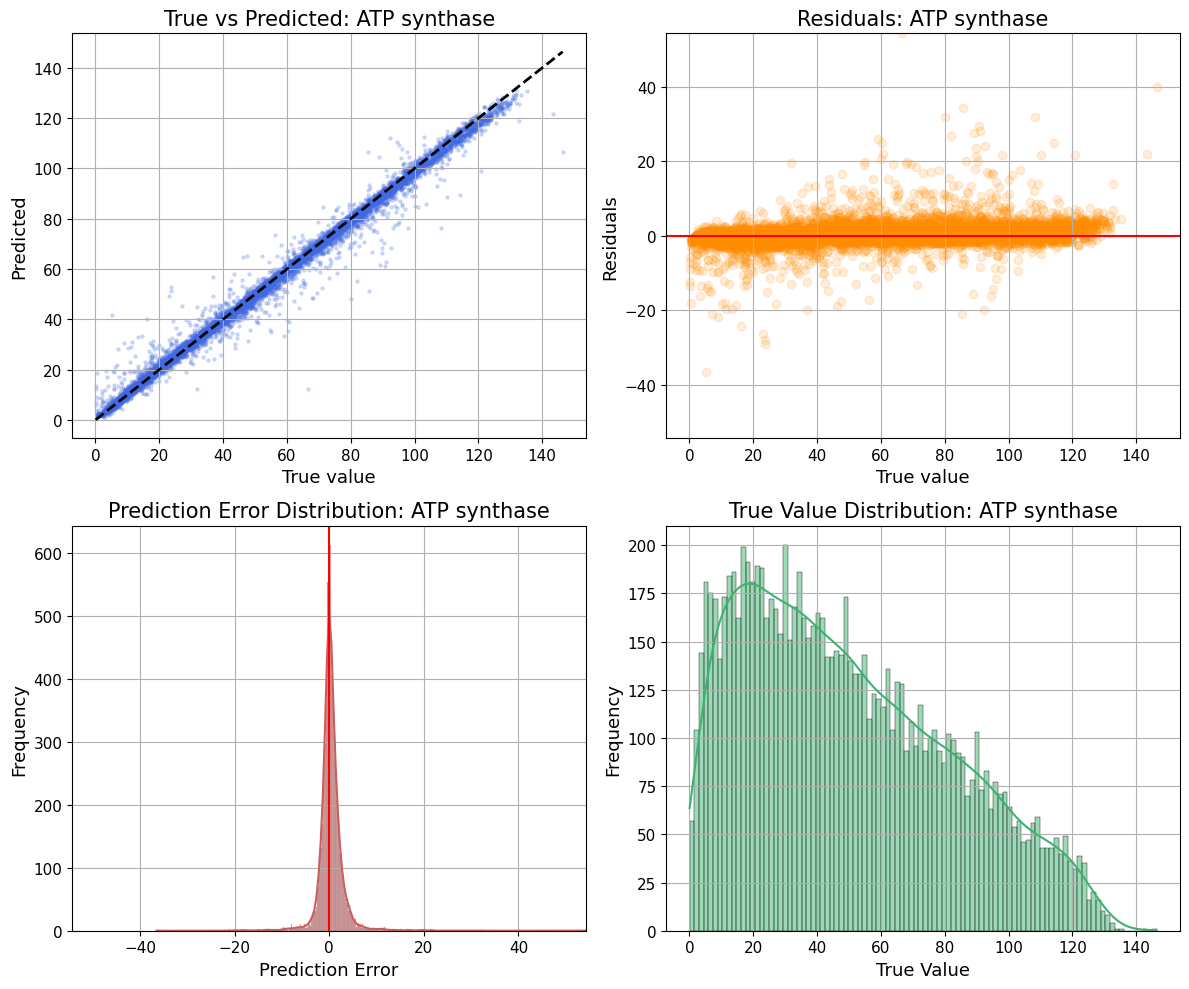

r_1245:
------------------------------------------------------------
Plotting flux 'r_1245' (column index 1037)
r_1245 y_true range: 0.0 .. 130.313720703125
r_1245 y_pred range: -2.5450878143310547 .. 126.3095703125
R2: 0.5244
MAE: 8.946585
RMSE: 20.539968


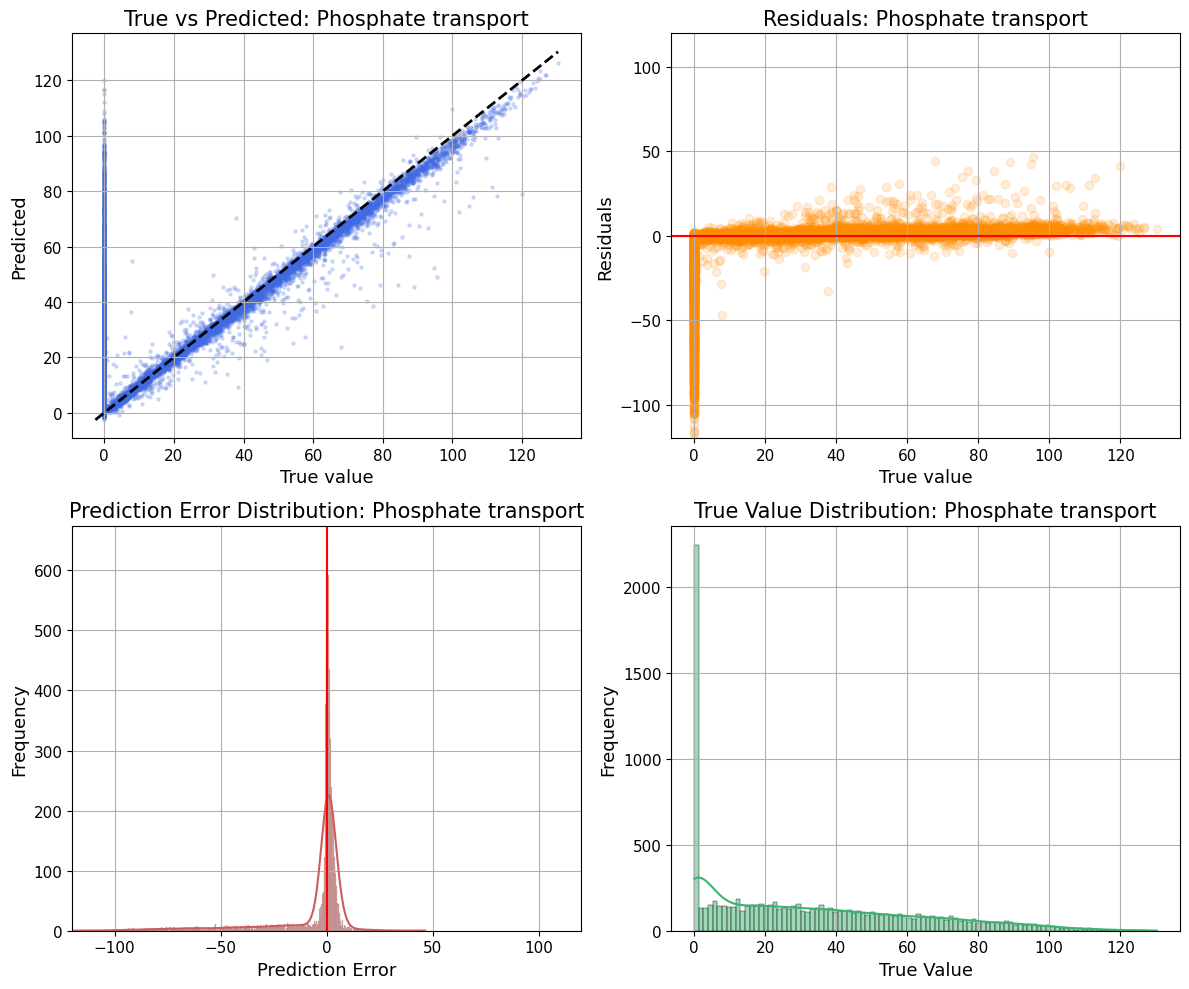

r_1021:
------------------------------------------------------------
Plotting flux 'r_1021' (column index 843)
r_1021 y_true range: -1.3403022421698552e-05 .. 97.60505676269531
r_1021 y_pred range: 0.2239365577697754 .. 90.18913269042969
R2: 0.4312
MAE: 11.023722
RMSE: 16.545551


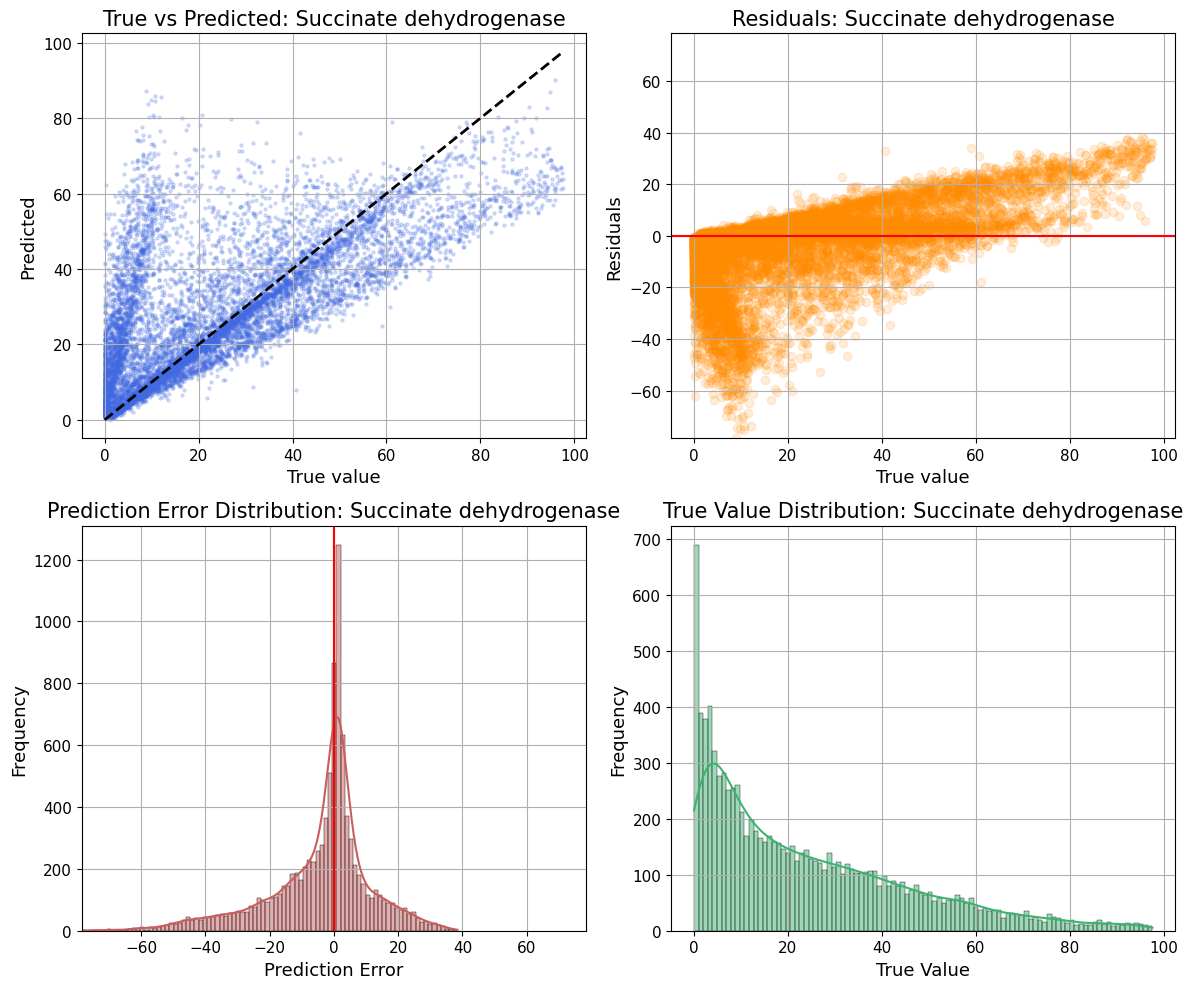

In [13]:
# Biomass plus representative high-flux energy and transport reactions.
# r_0438 and r_0226 test respiratory energy conversion; r_1245 and r_1021
# are high-flux reactions that also contribute strongly to total squared error.
diagnostics_to_plot = ['r_2111', 'r_1110', 'r_0438', 'r_0226', 'r_1245', 'r_1021']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

r_1810:
------------------------------------------------------------
Plotting flux 'r_1810' (column index 1316)
r_1810 y_true range: 0.0 .. 0.0
r_1810 y_pred range: -0.01759115606546402 .. 0.015142209827899933
R2: 0.0000
MAE: 0.002516
RMSE: 0.003312


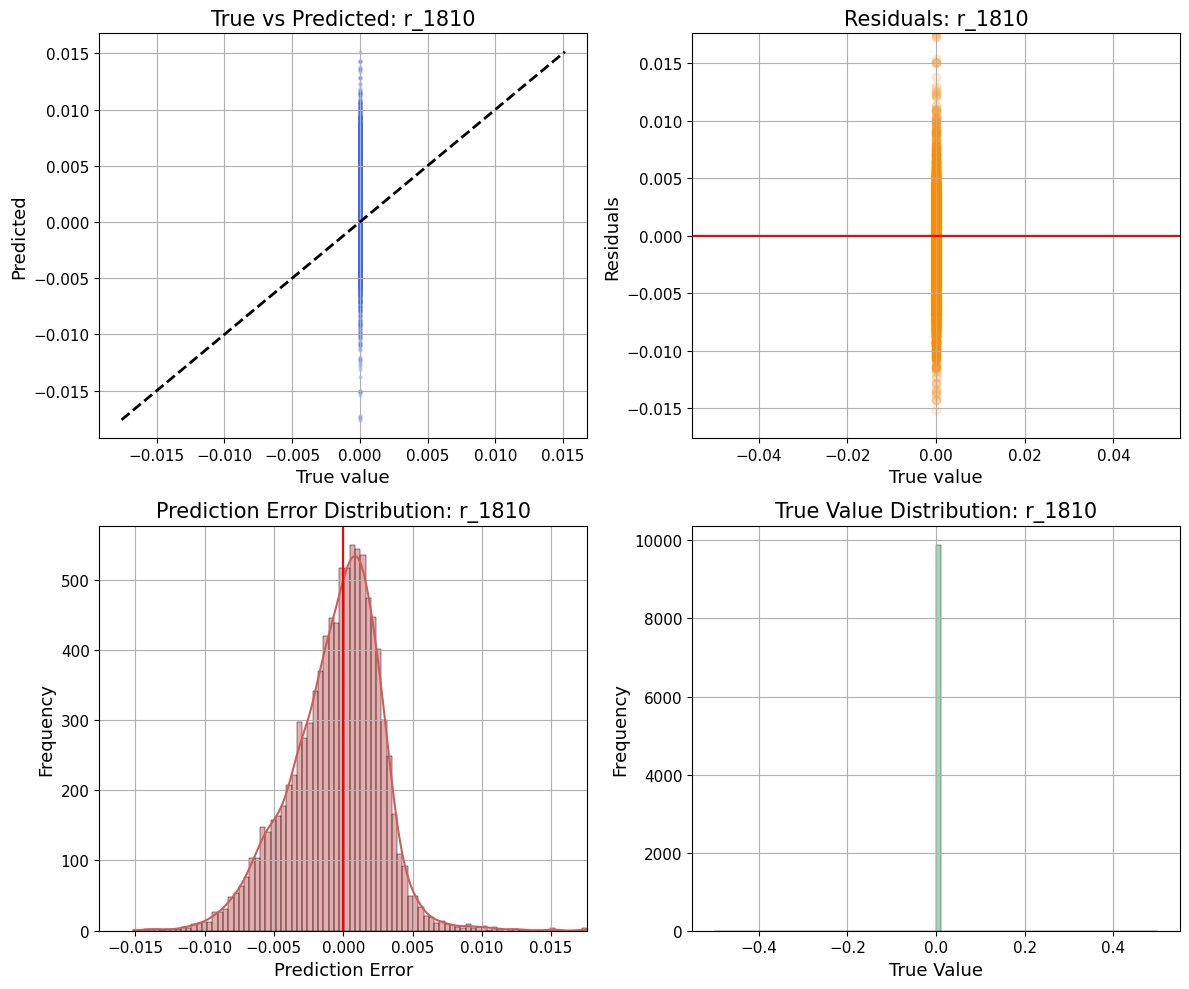

r_1873:
------------------------------------------------------------
Plotting flux 'r_1873' (column index 1378)
r_1873 y_true range: -9.979999542236328 .. 7.699708938598633
r_1873 y_pred range: -0.6957594156265259 .. 0.08345437049865723
R2: -0.0208
MAE: 0.442159
RMSE: 1.423928


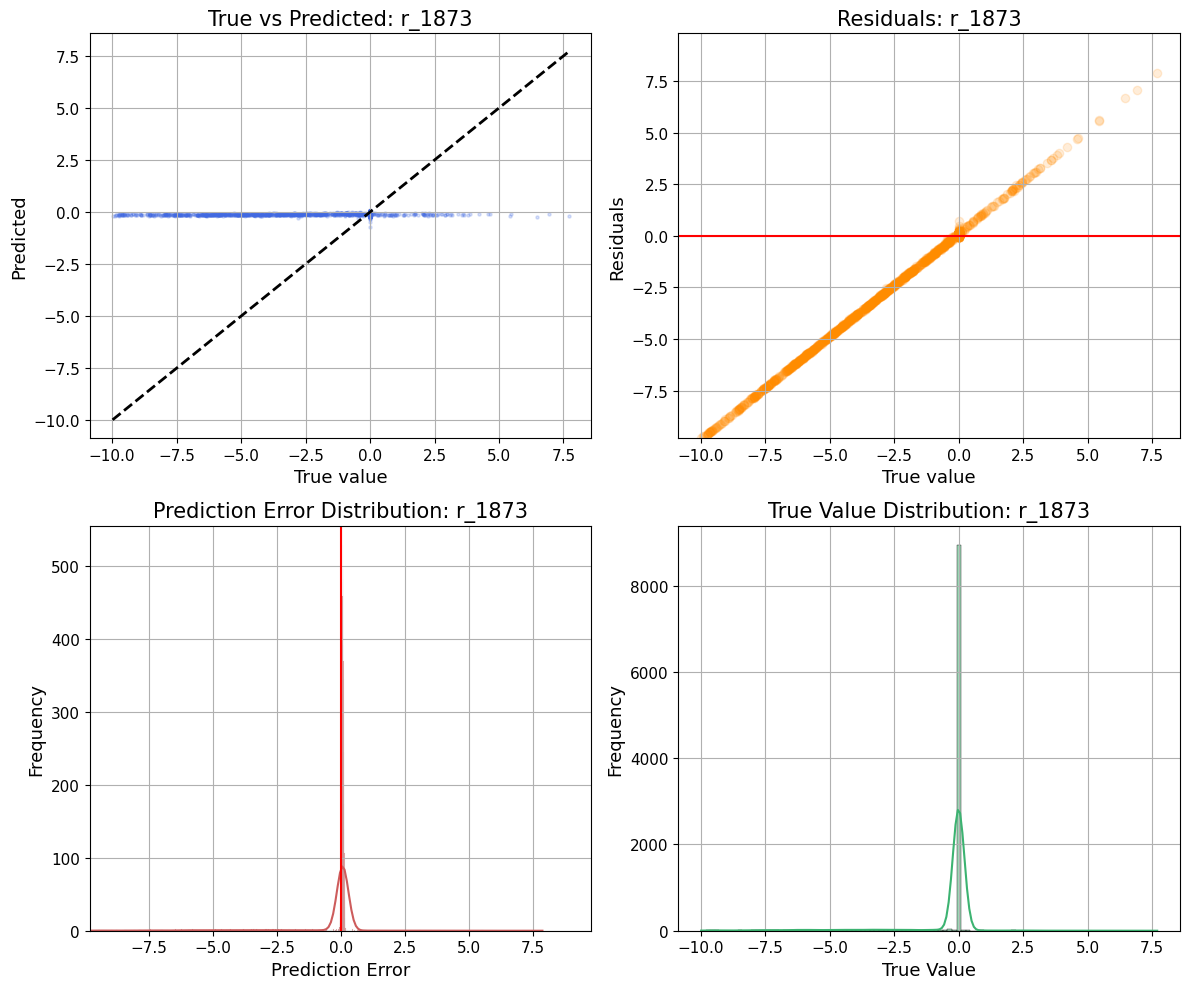

r_1889:
------------------------------------------------------------
Plotting flux 'r_1889' (column index 1393)
r_1889 y_true range: -10.0 .. 0.12175188213586807
r_1889 y_pred range: -9.937446594238281 .. 0.016733817756175995
R2: 0.9935
MAE: 0.036970
RMSE: 0.131276


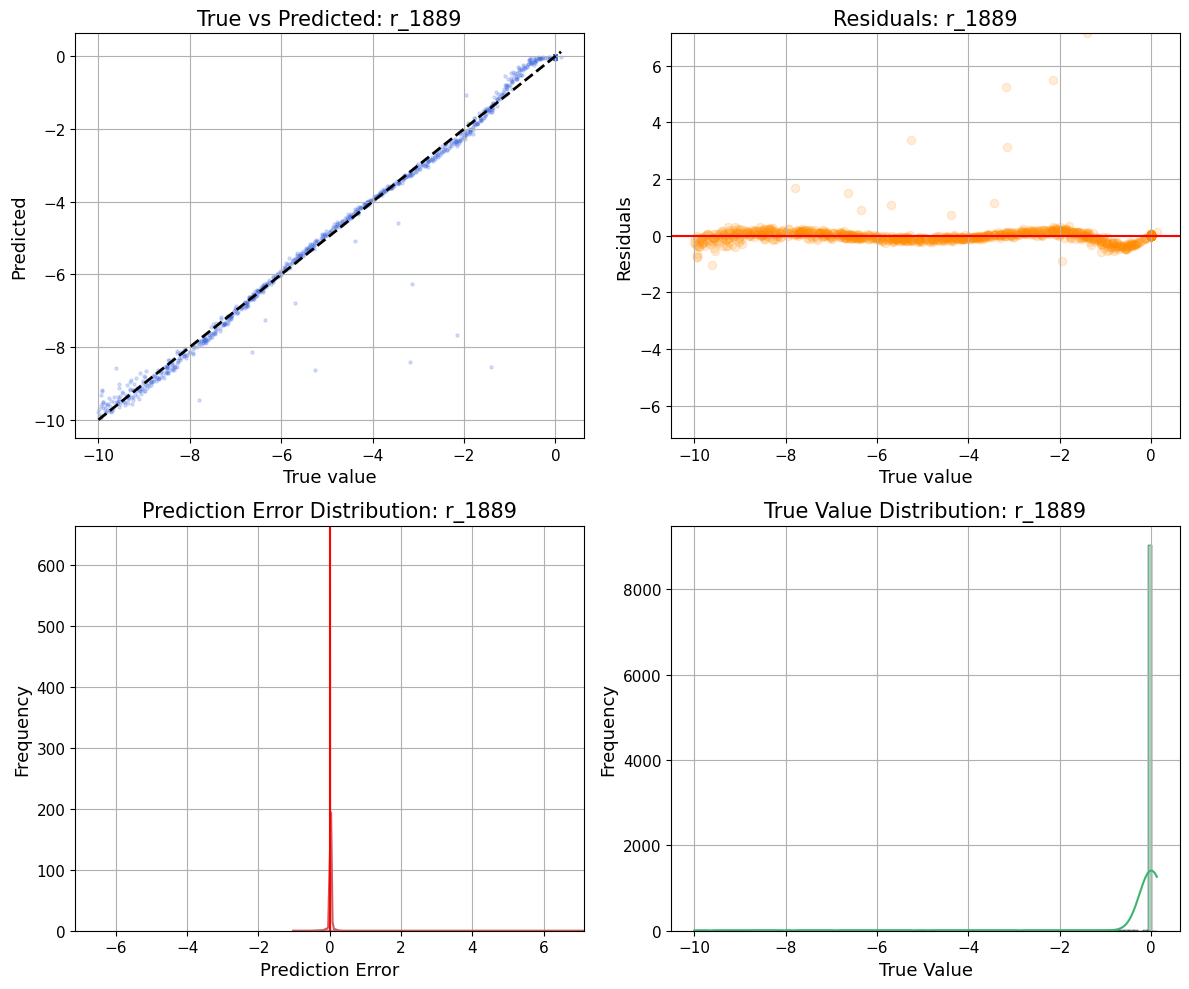

In [14]:
# Amino acids
# r_1810: L-glycine exchange
# r_1873: L-alanine exchange
# r_1889: L-glutamate exchange
diagnostics_to_plot = ['r_1810', 'r_1873', 'r_1889']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)


r_2100:
------------------------------------------------------------
Plotting flux 'r_2100' (column index 1554)
r_2100 y_true range: -16.682891845703125 .. 104.28714752197266
r_2100 y_pred range: -15.339838027954102 .. 98.41114807128906
R2: 0.9823
MAE: 1.509954
RMSE: 2.861032


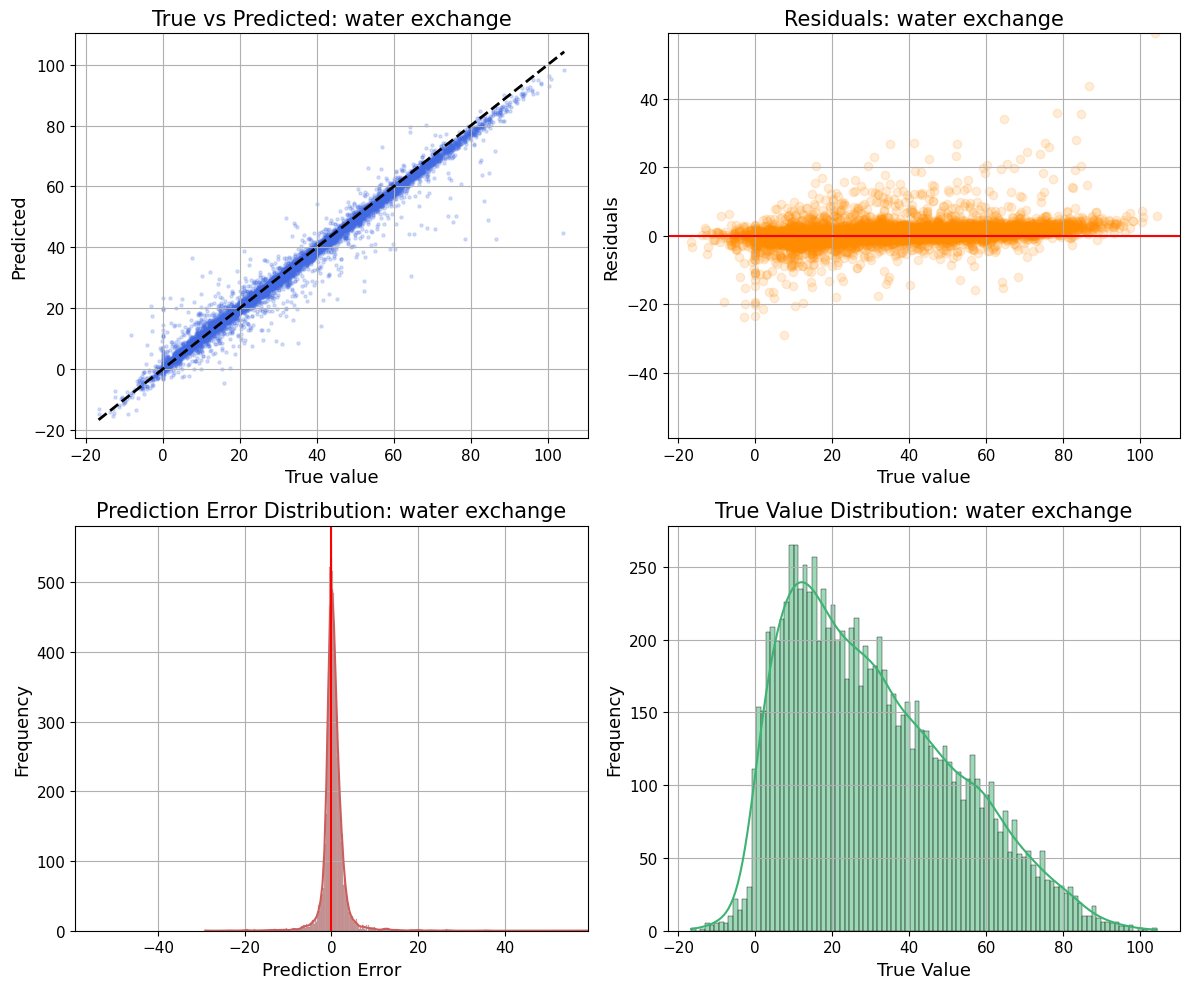

r_1672:
------------------------------------------------------------
Plotting flux 'r_1672' (column index 1204)
r_1672 y_true range: 0.22407589852809906 .. 148.4969024658203
r_1672 y_pred range: 0.705876350402832 .. 132.082763671875
R2: 0.9804
MAE: 1.855468
RMSE: 3.153743


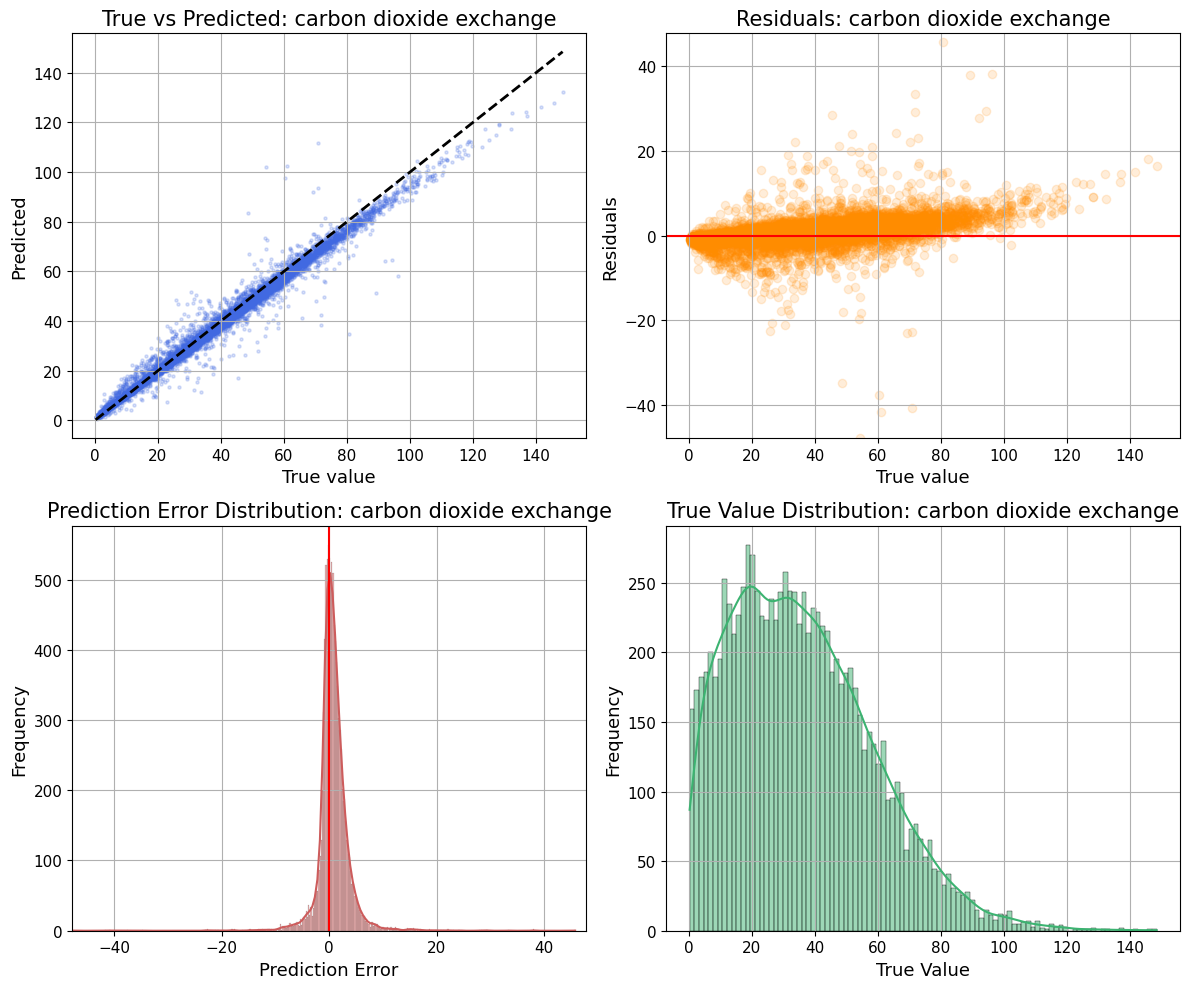

In [15]:
# r_2100	water exchange
# r_1672	carbon dioxide exchange

diagnostics_to_plot = ['r_2100', 'r_1672']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, input_cols, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png", batch_size=8)

In [16]:
# Overall test-set metrics across all model outputs (output_cols)
model = model.to(device)
model.eval()

pred_batches = []
true_batches = []
start_idx = len(input_cols)
end_idx = len(input_cols) + len(output_cols)
eval_batch_size = 8 if str(device).startswith('cuda') else 32
use_cuda_autocast = str(device).startswith('cuda')

with torch.inference_mode():
    for i in range(0, X_test.shape[0], eval_batch_size):
        xb = X_test[i:i+eval_batch_size].to(device)
        yb_true = y_test[i:i+eval_batch_size]

        c = xb.unsqueeze(-1)
        if use_cuda_autocast:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                yb_pred_t = model(c).squeeze(-1)
        else:
            yb_pred_t = model(c).squeeze(-1)

        yb_pred = yb_pred_t.float().cpu().numpy()
        yb_true_np = yb_true.cpu().numpy()

        pred_batches.append(yb_pred[:, start_idx:end_idx])
        true_batches.append(yb_true_np[:, start_idx:end_idx])

y_pred_all = np.concatenate(pred_batches, axis=0)
y_true_all = np.concatenate(true_batches, axis=0)

y_true_all64 = y_true_all.astype(np.float64, copy=False)
y_pred_all64 = y_pred_all.astype(np.float64, copy=False)
residual = y_true_all64 - y_pred_all64

ss_res = np.sum(residual ** 2, axis=0, dtype=np.float64)
y_true_mean = np.mean(y_true_all64, axis=0, dtype=np.float64)
ss_tot = np.sum((y_true_all64 - y_true_mean) ** 2, axis=0, dtype=np.float64)

# Robustly define active outputs: exclude near-constant targets.
positive_ss_tot = ss_tot[ss_tot > 0]
if positive_ss_tot.size > 0:
    ss_tot_threshold = max(1e-12, float(np.percentile(positive_ss_tot, 5)) * 1e-2)
else:
    ss_tot_threshold = 1e-12
active_mask = ss_tot > ss_tot_threshold

r2_per_flux = np.full(ss_tot.shape, np.nan, dtype=np.float64)
r2_per_flux[active_mask] = 1.0 - (ss_res[active_mask] / ss_tot[active_mask])

if np.any(active_mask):
    active_r2 = r2_per_flux[active_mask]
    r2_overall_mean = float(np.mean(active_r2))
    r2_overall_median = float(np.median(active_r2))
    r2_overall_var_weighted = float(np.average(active_r2, weights=ss_tot[active_mask]))
else:
    r2_overall_mean = np.nan
    r2_overall_median = np.nan
    r2_overall_var_weighted = np.nan

r2_pooled = float(r2_score(y_true_all64.ravel(), y_pred_all64.ravel()))
mae_overall = mean_absolute_error(y_true_all64.ravel(), y_pred_all64.ravel())
rmse_overall = float(np.sqrt(np.mean(residual ** 2, dtype=np.float64)))

n_active = int(np.sum(active_mask))
n_total = int(active_mask.size)
print('Overall model metrics (all output_cols):')
print(f'R2 (pooled outputs):                {r2_pooled:.4f}')
print(f'R2 (active outputs, median):       {r2_overall_median:.4f}')
print(f'R2 (active outputs, mean):         {r2_overall_mean:.4f}')
print(f'R2 (active outputs, var-weighted): {r2_overall_var_weighted:.4f}')
print(f'Active outputs used for R2:        {n_active}/{n_total}')
print(f'SS_tot active threshold:           {ss_tot_threshold:.3e}')
print(f'MAE:                               {mae_overall:.6f}')
print(f'RMSE:                              {rmse_overall:.6f}')


Overall model metrics (all output_cols):
R2 (pooled outputs):                0.9116
R2 (active outputs, median):       -3.2708
R2 (active outputs, mean):         -56874588.4001
R2 (active outputs, var-weighted): 0.7744
Active outputs used for R2:        2327/4131
SS_tot active threshold:           1.000e-12
MAE:                               0.064661
RMSE:                              1.002208


### Overall and Difficult-Flux Diagnostics


In [17]:
# Pooled metric summary
pooled_metrics_df = pd.DataFrame(
    [
        {"metric": "Pooled R2", "value": r2_pooled},
        {"metric": "MAE", "value": mae_overall},
        {"metric": "RMSE", "value": rmse_overall},
        {"metric": "Active outputs", "value": f"{n_active}/{n_total}"},
    ]
)

print(f"Pooled flux R2: {r2_pooled:.4f}")
print(f"Pooled flux MAE: {mae_overall:.6f}")
print(f"Pooled flux RMSE: {rmse_overall:.6f}")
display(pooled_metrics_df)


Pooled flux R2: 0.9116
Pooled flux MAE: 0.064661
Pooled flux RMSE: 1.002208


,metric,value
0,Pooled R2,0.911594
1,MAE,0.064661
2,RMSE,1.002208
3,Active outputs,2327/4131


In [18]:
# Reaction-level error diagnostics for difficult-flux selection
err = (y_pred_all - y_true_all).astype(np.float64, copy=False)
abs_err = np.abs(err)

mae_per_flux = np.mean(abs_err, axis=0)
rmse_per_flux = np.sqrt(np.mean(err ** 2, axis=0))
p95_abs_err_per_flux = np.percentile(abs_err, 95, axis=0)
true_std_per_flux = np.std(y_true_all64, axis=0)
zero_fraction_per_flux = np.mean(np.isclose(y_true_all64, 0.0, atol=1e-12), axis=0)

sse_per_flux = np.sum(err ** 2, axis=0, dtype=np.float64)
total_sse = float(np.sum(sse_per_flux))
sse_share_per_flux = sse_per_flux / total_sse if total_sse > 0 else np.zeros_like(sse_per_flux)

ss_tot_diag = np.sum((y_true_all64 - np.mean(y_true_all64, axis=0, dtype=np.float64)) ** 2, axis=0, dtype=np.float64)
positive_ss_tot_diag = ss_tot_diag[ss_tot_diag > 0]
if positive_ss_tot_diag.size > 0:
    ss_tot_diag_threshold = max(1e-12, float(np.percentile(positive_ss_tot_diag, 5)) * 1e-2)
else:
    ss_tot_diag_threshold = 1e-12
active_mask_diag = ss_tot_diag > ss_tot_diag_threshold

r2_per_flux_diag = np.full(ss_tot_diag.shape, np.nan, dtype=np.float64)
r2_per_flux_diag[active_mask_diag] = 1.0 - (sse_per_flux[active_mask_diag] / ss_tot_diag[active_mask_diag])
rmse_mae_ratio = rmse_per_flux / np.maximum(mae_per_flux, 1e-12)

flux_metrics_df = pd.DataFrame(
    {
        "flux": output_cols,
        "reaction_name": [reaction_name_map[flux] for flux in output_cols],
        "active": active_mask_diag,
        "R2": r2_per_flux_diag,
        "MAE": mae_per_flux,
        "RMSE": rmse_per_flux,
        "true_std": true_std_per_flux,
        "zero_fraction": zero_fraction_per_flux,
        "P95_abs_error": p95_abs_err_per_flux,
        "RMSE_MAE_ratio": rmse_mae_ratio,
        "SSE_share": sse_share_per_flux,
    }
)

top_k = min(20, len(output_cols))
largest_error_fluxes_df = (
    flux_metrics_df.sort_values("SSE_share", ascending=False)
    .head(top_k)
    .reset_index(drop=True)
)

active_flux_metrics_df = flux_metrics_df[flux_metrics_df["active"]].copy()
hard_fluxes_by_r2_df = (
    active_flux_metrics_df.sort_values(["R2", "SSE_share"], ascending=[True, False])
    .head(top_k)
    .reset_index(drop=True)
)

top5_sse_share = float(largest_error_fluxes_df["SSE_share"].head(5).sum())
top10_sse_share = float(largest_error_fluxes_df["SSE_share"].head(10).sum())

print("Reaction-level flux metrics:")
print(f"Active outputs for per-flux R2: {int(active_mask_diag.sum())}/{len(output_cols)}")
print(f"Top 5 fluxes account for {top5_sse_share:.2%} of total squared error")
print(f"Top 10 fluxes account for {top10_sse_share:.2%} of total squared error")
print(f"Median RMSE/MAE ratio across fluxes: {np.median(rmse_mae_ratio):.2f}")
print(f"90th percentile RMSE/MAE ratio: {np.percentile(rmse_mae_ratio, 90):.2f}")

print("\nLargest contributors to total squared error:")
display(
    largest_error_fluxes_df[
        ["flux", "reaction_name", "R2", "MAE", "RMSE", "true_std", "zero_fraction", "SSE_share"]
    ].style.format(
        {
            "R2": "{:.4f}",
            "MAE": "{:.6f}",
            "RMSE": "{:.6f}",
            "true_std": "{:.6f}",
            "zero_fraction": "{:.2%}",
            "SSE_share": "{:.2%}",
        }
    )
)

print("\nLowest active-flux R2 values:")
display(
    hard_fluxes_by_r2_df[
        ["flux", "reaction_name", "R2", "MAE", "RMSE", "true_std", "zero_fraction", "SSE_share"]
    ].style.format(
        {
            "R2": "{:.4f}",
            "MAE": "{:.6f}",
            "RMSE": "{:.6f}",
            "true_std": "{:.6f}",
            "zero_fraction": "{:.2%}",
            "SSE_share": "{:.2%}",
        }
    )
)

# Upper-tail compression and activity-frequency summaries. These use the
# predictions already collected above and require no additional model pass.
abs_true = np.abs(y_true_all64)
abs_pred = np.abs(y_pred_all64)
true_q90_abs = np.percentile(abs_true, 90, axis=0)
true_q95_abs = np.percentile(abs_true, 95, axis=0)
pred_q95_abs = np.percentile(abs_pred, 95, axis=0)
q95_magnitude_ratio = np.divide(
    pred_q95_abs, true_q95_abs,
    out=np.full_like(pred_q95_abs, np.nan, dtype=np.float64),
    where=true_q95_abs > 1e-8,
)

upper_tail_magnitude_bias = np.full(len(output_cols), np.nan, dtype=np.float64)
upper_tail_underprediction_rate = np.full(len(output_cols), np.nan, dtype=np.float64)
for j in range(len(output_cols)):
    if true_q90_abs[j] <= 1e-8:
        continue
    upper_mask = abs_true[:, j] >= true_q90_abs[j]
    upper_tail_magnitude_bias[j] = np.median(abs_pred[upper_mask, j] - abs_true[upper_mask, j])
    upper_tail_underprediction_rate[j] = np.mean(abs_pred[upper_mask, j] < abs_true[upper_mask, j])

activity_tolerance = 1e-8
active_fraction = np.mean(abs_true > activity_tolerance, axis=0)
flux_metrics_df["active_fraction"] = active_fraction
flux_metrics_df["true_q95_abs"] = true_q95_abs
flux_metrics_df["pred_q95_abs"] = pred_q95_abs
flux_metrics_df["q95_magnitude_ratio"] = q95_magnitude_ratio
flux_metrics_df["upper_tail_magnitude_bias"] = upper_tail_magnitude_bias
flux_metrics_df["upper_tail_underprediction_rate"] = upper_tail_underprediction_rate

selected_high_fluxes = ["r_1110", "r_0438", "r_0226", "r_1245", "r_1021", "r_2100", "r_1672"]
print("\nUpper-tail diagnostics for selected high-flux reactions:")
display(
    flux_metrics_df.set_index("flux").loc[selected_high_fluxes].reset_index()[
        ["flux", "reaction_name", "R2", "active_fraction", "true_q95_abs",
         "pred_q95_abs", "q95_magnitude_ratio", "upper_tail_magnitude_bias",
         "upper_tail_underprediction_rate"]
    ].style.format({
        "R2": "{:.4f}", "active_fraction": "{:.2%}",
        "true_q95_abs": "{:.4f}", "pred_q95_abs": "{:.4f}",
        "q95_magnitude_ratio": "{:.3f}", "upper_tail_magnitude_bias": "{:.4f}",
        "upper_tail_underprediction_rate": "{:.2%}",
    })
)

activity_bins = [0.0, 0.01, 0.10, 0.50, 1.0]
activity_labels = ["<1%", "1-10%", "10-50%", ">50%"]
activity_group = pd.cut(
    active_fraction, bins=activity_bins, labels=activity_labels,
    include_lowest=True, right=True,
)
activity_summary_rows = []
for label in activity_labels:
    mask = np.asarray(activity_group == label)
    stable_r2_mask = mask & (true_std_per_flux >= 1e-6)
    activity_summary_rows.append({
        "activity_group": label,
        "n_reactions": int(mask.sum()),
        "median_true_std": float(np.median(true_std_per_flux[mask])) if mask.any() else np.nan,
        "median_MAE": float(np.median(mae_per_flux[mask])) if mask.any() else np.nan,
        "median_R2_variable": float(np.median(r2_per_flux_diag[stable_r2_mask])) if stable_r2_mask.any() else np.nan,
        "n_R2_variable": int(stable_r2_mask.sum()),
    })
activity_summary_df = pd.DataFrame(activity_summary_rows)
print("\nReaction performance grouped by true-flux activity frequency:")
display(activity_summary_df.style.format({
    "median_true_std": "{:.6f}", "median_MAE": "{:.6f}",
    "median_R2_variable": "{:.4f}",
}))


Reaction-level flux metrics:
Active outputs for per-flux R2: 2327/4131
Top 5 fluxes account for 35.63% of total squared error
Top 10 fluxes account for 57.68% of total squared error
Median RMSE/MAE ratio across fluxes: 1.27
90th percentile RMSE/MAE ratio: 3.30

Largest contributors to total squared error:


,flux,reaction_name,R2,MAE,RMSE,true_std,zero_fraction,SSE_share
0,r_1245,phosphate transport,0.5245,8.948253,20.538221,29.782944,21.62%,10.17%
1,r_1021,succinate dehydrogenase (ubiquinone-6),0.4312,11.024391,16.544941,21.937684,0.50%,6.60%
2,r_0454,fumarate reductase,-0.0364,10.196356,16.399542,16.109264,49.16%,6.48%
3,r_0490,glycerol-3-phosphate dehydrogenase (fad),-0.0224,10.180073,16.289069,16.109252,49.78%,6.39%
4,r_0770,"NADH dehydrogenase, cytosolic/mitochondrial",-0.2703,8.110250,15.761446,13.984182,60.05%,5.99%
5,r_0491,glycerol-3-phosphate dehydrogenase (NAD),-0.2295,6.880322,14.380150,12.968798,44.40%,4.98%
6,r_1809,glycerol-3-phosphate shuttle,-0.2259,6.842500,14.367789,12.976790,22.40%,4.98%
7,r_1746,dihydroxyacetone phosphate transport,-0.2258,6.841858,14.367312,12.976790,22.40%,4.97%
8,r_1265,succinate-fumarate transport,-0.1307,4.977086,12.163411,11.439062,3.97%,3.57%
9,r_0441,FMN reductase,-0.1569,4.944469,12.140504,11.287179,73.47%,3.55%



Lowest active-flux R2 values:


,flux,reaction_name,R2,MAE,RMSE,true_std,zero_fraction,SSE_share
0,r_1916,laurate exchange,-100637248639.9067,0.010638,0.011373,0.000000,99.99%,0.00%
1,r_2186,laurate (n-C12:0) transport,-23009400244.8313,0.004327,0.005438,0.000000,99.99%,0.00%
2,r_2185,decanoate (n-C10:0) transport,-1029062480.7649,0.006176,0.006902,0.000000,99.97%,0.00%
3,r_1034,thiamine diphosphokinase,-940973785.6213,0.001490,0.001842,0.000000,98.30%,0.00%
4,r_1727,decanoate exchange,-745328382.3435,0.003674,0.005874,0.000000,99.97%,0.00%
5,r_1984,octanoate exchange,-661901728.8754,0.006736,0.007609,0.000000,99.99%,0.00%
6,r_2184,octanoate (n-C8:0) transport,-614776941.7168,0.006306,0.007333,0.000000,99.99%,0.00%
7,r_1770,fatty acid transport,-376002689.9661,0.003871,0.004172,0.000000,99.97%,0.00%
8,r_1790,FMN adenylyltransferase,-352802504.9888,0.016027,0.017286,0.000001,98.32%,0.00%
9,r_0530,heme O monooxygenase,-310966311.0039,0.008870,0.009909,0.000001,0.31%,0.00%



Upper-tail diagnostics for selected high-flux reactions:


,flux,reaction_name,R2,active_fraction,true_q95_abs,pred_q95_abs,q95_magnitude_ratio,upper_tail_magnitude_bias,upper_tail_underprediction_rate
0,r_1110,ADP/ATP transporter,0.9923,99.98%,119.6137,118.3513,0.989,-1.1943,78.14%
1,r_0438,ferrocytochrome-c:oxygen oxidoreductase,0.9928,99.98%,166.8712,164.7396,0.987,-2.1050,96.46%
2,r_0226,ATP synthase,0.9916,100.00%,109.6415,108.5610,0.990,-1.7629,74.80%
3,r_1245,phosphate transport,0.5245,78.38%,88.9865,88.1680,0.991,-3.1751,95.24%
4,r_1021,succinate dehydrogenase (ubiquinone-6),0.4312,99.50%,68.8864,60.5644,0.879,-17.9986,95.45%
5,r_2100,water exchange,0.9823,99.40%,70.6913,68.6232,0.971,-2.0123,92.21%
6,r_1672,carbon dioxide exchange,0.9803,100.00%,76.3609,73.4425,0.962,-3.3978,94.03%



Reaction performance grouped by true-flux activity frequency:


,activity_group,n_reactions,median_true_std,median_MAE,median_R2_variable,n_R2_variable
0,<1%,2869,0.000000,0.004283,-93.8652,1045
1,1-10%,571,0.003570,0.006663,-1.4687,562
2,10-50%,195,0.009027,0.007871,-0.3306,195
3,>50%,496,0.068543,0.018147,0.5398,475


Difficult fluxes selected for diagnostic plots:


,flux,reaction_name,R2,MAE,RMSE,true_std,zero_fraction,SSE_share
384,r_0491,glycerol-3-phosphate dehydrogenase (NAD),-0.2295,6.880322,14.380150,12.968798,44.40%,4.98%
512,r_0649,IPS phospholipase C,-43191.6203,0.019212,0.025079,0.000121,99.97%,0.00%
618,r_0770,"NADH dehydrogenase, cytosolic/mitochondrial",-0.2703,8.110250,15.761446,13.984182,60.05%,5.99%
1651,r_2274,3-hydroxyacyl-CoA dehydrogenase (3-oxoicosanoyl-CoA),-1393.9646,0.021866,0.031448,0.000842,99.77%,0.00%


r_0649:
------------------------------------------------------------
Plotting flux 'r_0649' (column index 576)
r_0649 y_true range: -3.0115888344254062e-19 .. 0.00839909352362156
r_0649 y_pred range: -0.12668520212173462 .. 0.1753993034362793
R2: -43175.9922
MAE: 0.019207
RMSE: 0.025075


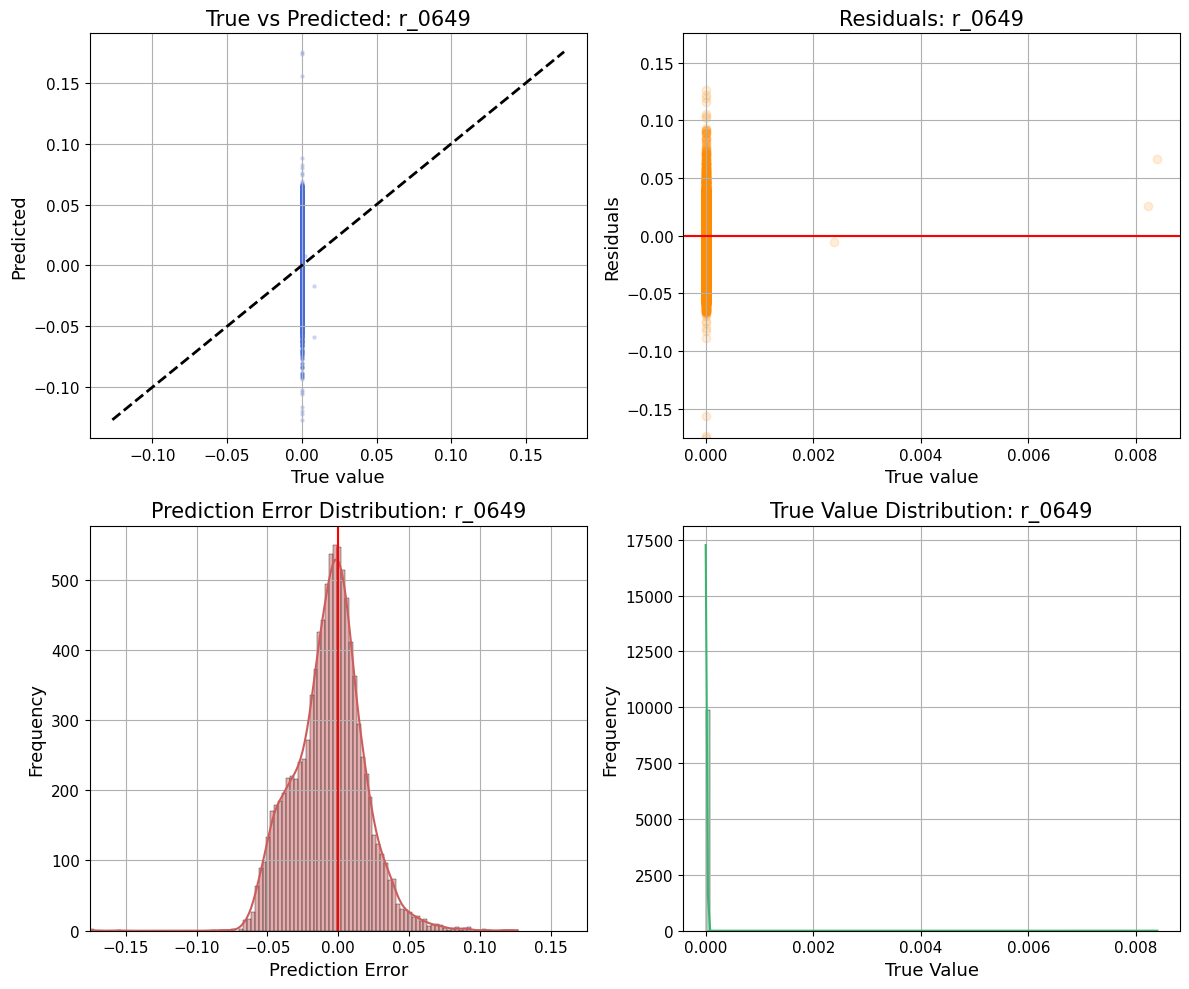

r_0770:
------------------------------------------------------------
Plotting flux 'r_0770' (column index 682)
r_0770 y_true range: 0.0 .. 86.75596618652344
r_0770 y_pred range: 0.18104100227355957 .. 0.8446078896522522
R2: -0.2703
MAE: 8.110225
RMSE: 15.761499


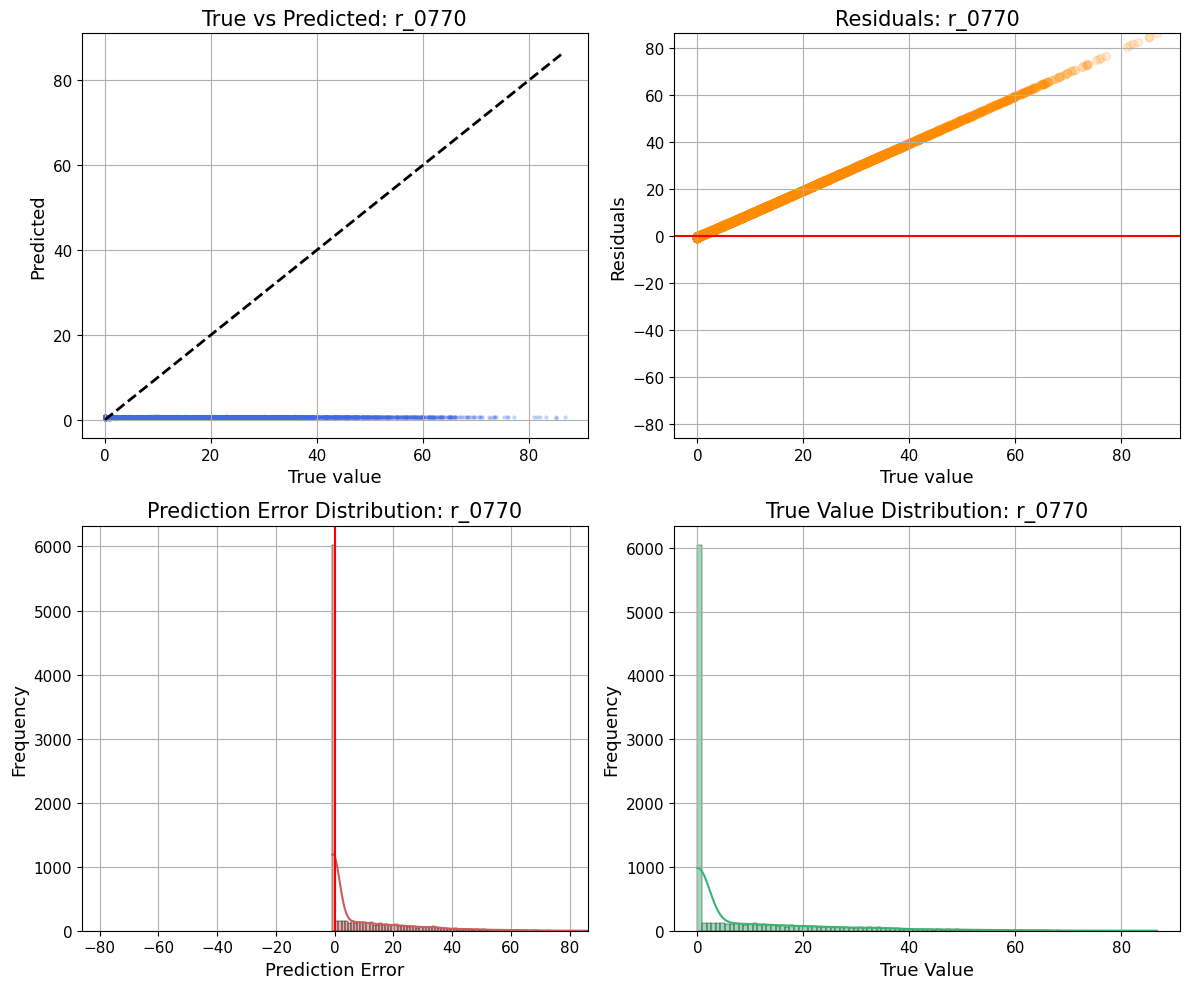

r_2274:
------------------------------------------------------------
Plotting flux 'r_2274' (column index 1715)
r_2274 y_true range: -2.276933524537894e-13 .. 0.047482240945100784
r_2274 y_pred range: -0.08308158814907074 .. 0.30039042234420776
R2: -1392.1249
MAE: 0.021862
RMSE: 0.031427


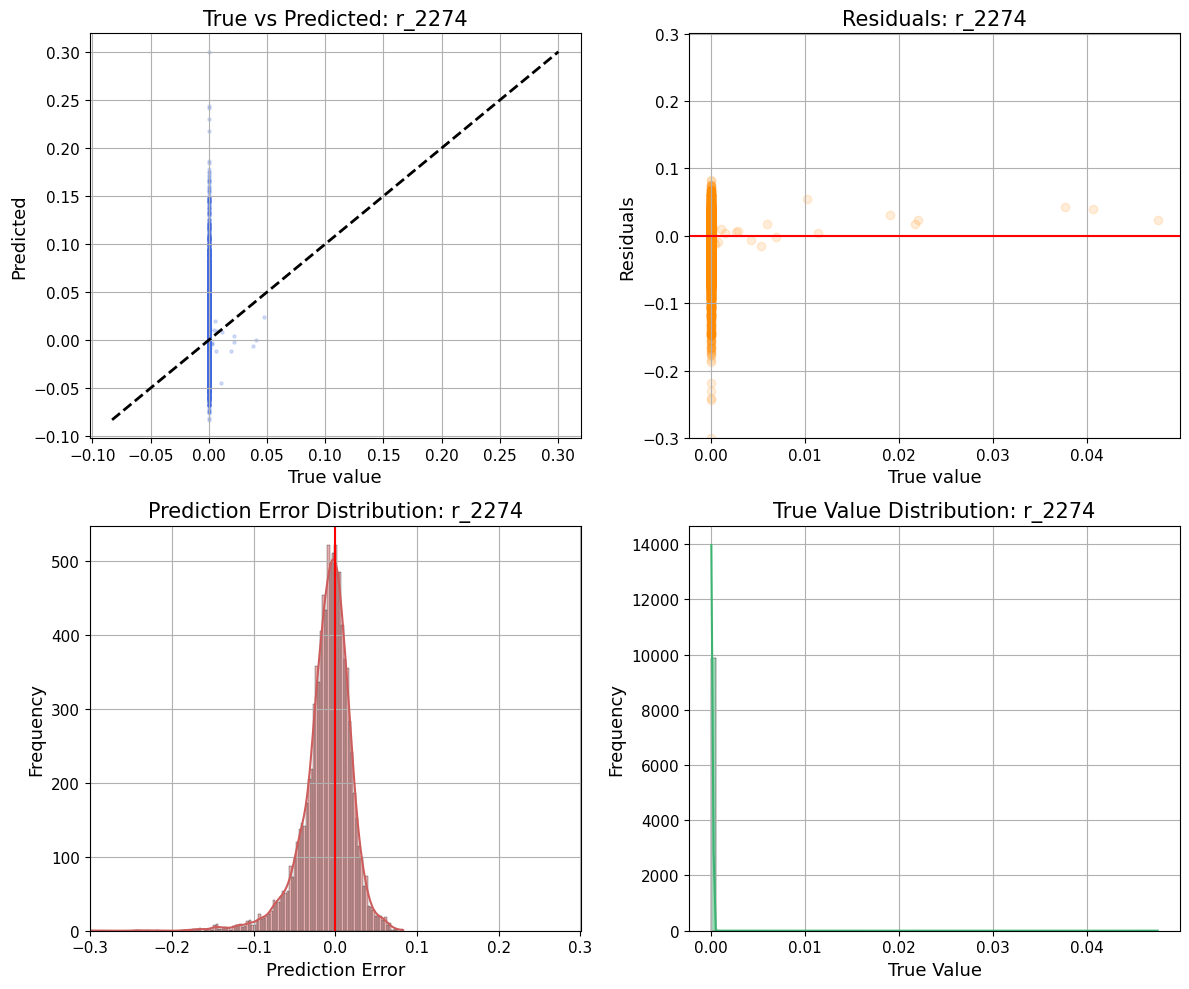

r_0491:
------------------------------------------------------------
Plotting flux 'r_0491' (column index 448)
r_0491 y_true range: -1.5876499358842662e-18 .. 86.98004150390625
r_0491 y_pred range: 0.3085091710090637 .. 4.561849117279053
R2: -0.2295
MAE: 6.880322
RMSE: 14.380146


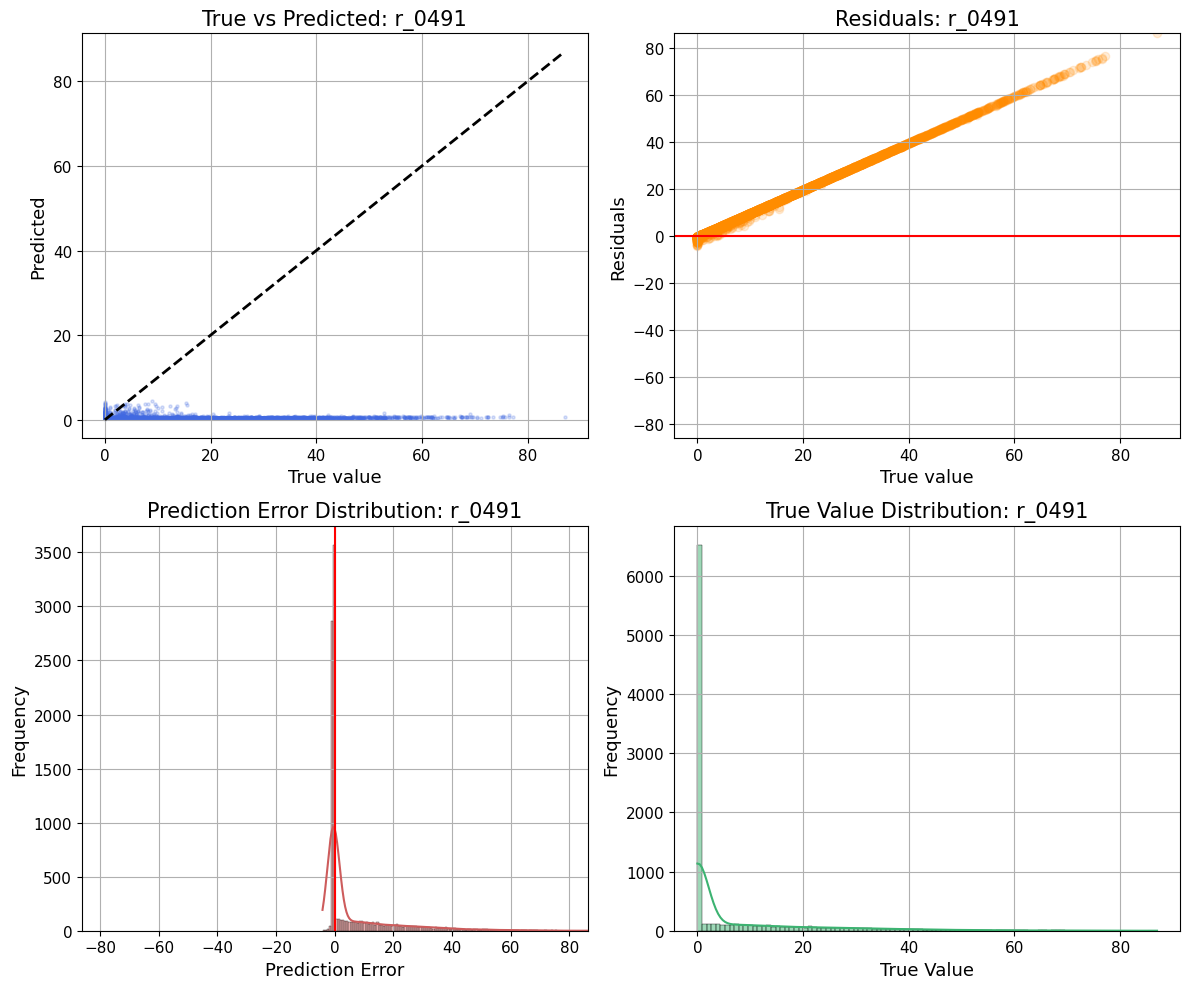

In [19]:
# Plot automatically selected difficult fluxes
already_plotted_fluxes = {
    "r_2111", "r_1110", "r_0438", "r_0226", "r_1245", "r_1021",
    "r_2100", "r_1672",
}

difficult_candidates_df = active_flux_metrics_df[
    ~active_flux_metrics_df["flux"].isin(already_plotted_fluxes)
].copy()

# Balance low R2 with large absolute error so the examples are both hard and visible.
difficult_candidates_df["difficulty_rank"] = (
    difficult_candidates_df["R2"].rank(method="min", ascending=True)
    + difficult_candidates_df["RMSE"].rank(method="min", ascending=False)
    + difficult_candidates_df["SSE_share"].rank(method="min", ascending=False)
)

difficult_fluxes_to_plot = (
    difficult_candidates_df.sort_values(["difficulty_rank", "R2", "SSE_share"], ascending=[True, True, False])
    .head(4)["flux"]
    .tolist()
)

print("Difficult fluxes selected for diagnostic plots:")
display(
    flux_metrics_df[flux_metrics_df["flux"].isin(difficult_fluxes_to_plot)][
        ["flux", "reaction_name", "R2", "MAE", "RMSE", "true_std", "zero_fraction", "SSE_share"]
    ].style.format(
        {
            "R2": "{:.4f}",
            "MAE": "{:.6f}",
            "RMSE": "{:.6f}",
            "true_std": "{:.6f}",
            "zero_fraction": "{:.2%}",
            "SSE_share": "{:.2%}",
        }
    )
)

for flux_name in difficult_fluxes_to_plot:
    print(f"{flux_name}:")
    print(60 * "-")
    plot_flux(
        model,
        X_test,
        y_test,
        input_cols,
        output_cols,
        flux_name,
        save_path=f"{pic_dir}/{flux_name}_difficult.png",
        batch_size=8,
    )
